<a href="https://colab.research.google.com/github/Anshikaydv/Aeroblast-Project/blob/main/Aeroblast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**To run this notebook yourself:**
You will be prompted to upload the file `AirfoilSelfNoise.csv` when you run the first code cell. If you don't have the file, just review the code and the outputs below.

In [ ]:
from google.colab import files
import pandas as pd
import io

# Prompt user to upload the CSV
uploaded = files.upload()  # User will be prompted to upload AirfoilSelfNoise.csv

# Read the uploaded file
for filename in uploaded.keys():
    df = pd.read_csv(io.BytesIO(uploaded[filename]))
    break  # Only process the first file

# Preview the loaded data
print(df.head())

Saving AirfoilSelfNoise.csv to AirfoilSelfNoise (1).csv
      f  alpha       c  U_infinity     delta     SSPL
0   800    0.0  0.3048        71.3  0.002663  126.201
1  1000    0.0  0.3048        71.3  0.002663  125.201
2  1250    0.0  0.3048        71.3  0.002663  125.951
3  1600    0.0  0.3048        71.3  0.002663  127.591
4  2000    0.0  0.3048        71.3  0.002663  127.461


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('AirfoilSelfNoise.csv')
df.head()

,f,alpha,c,U_infinity,delta,SSPL
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


In [ ]:
# Check data types and summary
print(df.info())
print(df.describe())

# Check for any missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   f           1503 non-null   int64  
 1   alpha       1503 non-null   float64
 2   c           1503 non-null   float64
 3   U_infinity  1503 non-null   float64
 4   delta       1503 non-null   float64
 5   SSPL        1503 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 70.6 KB
None
                  f        alpha            c   U_infinity        delta  \
count   1503.000000  1503.000000  1503.000000  1503.000000  1503.000000   
mean    2886.380572     6.782302     0.136548    50.860745     0.011140   
std     3152.573137     5.918128     0.093541    15.572784     0.013150   
min      200.000000     0.000000     0.025400    31.700000     0.000401   
25%      800.000000     2.000000     0.050800    39.600000     0.002535   
50%     1600.000000     5.400000     0.101600    39.600000  

,0
f,0
alpha,0
c,0
U_infinity,0
delta,0
SSPL,0


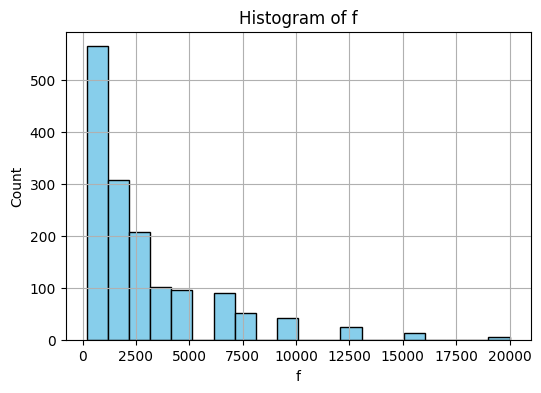

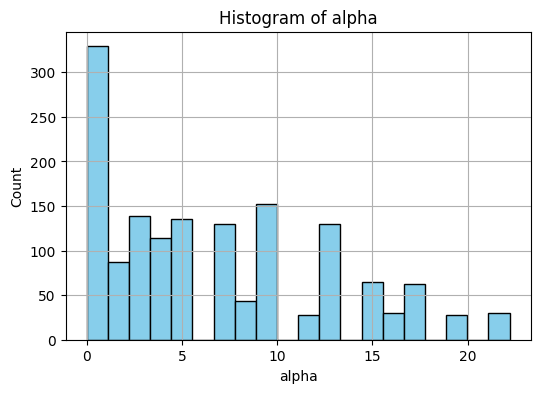

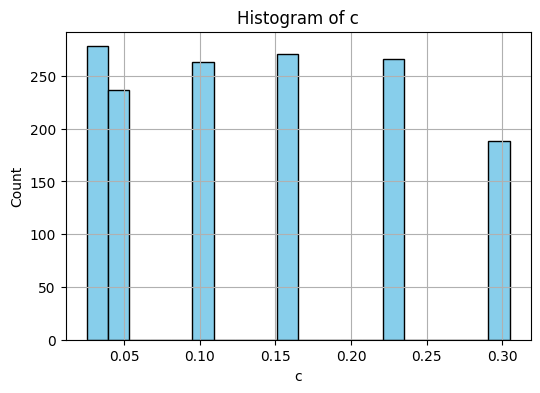

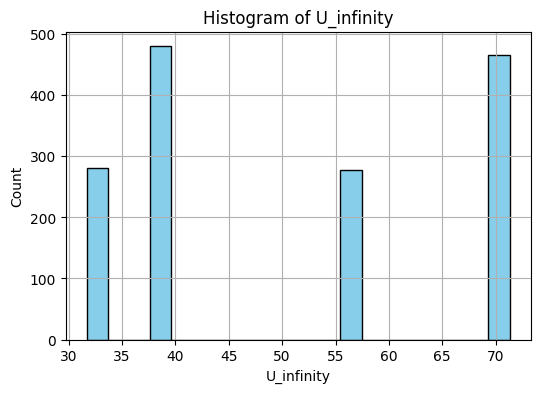

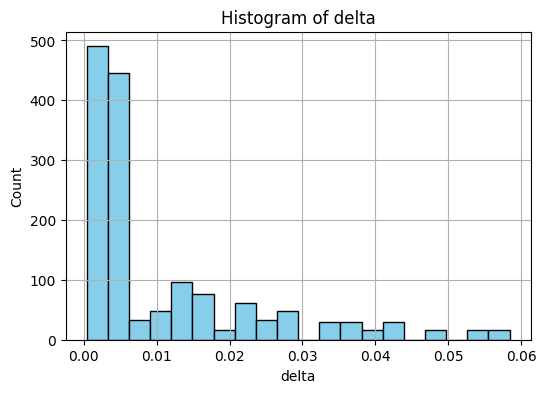

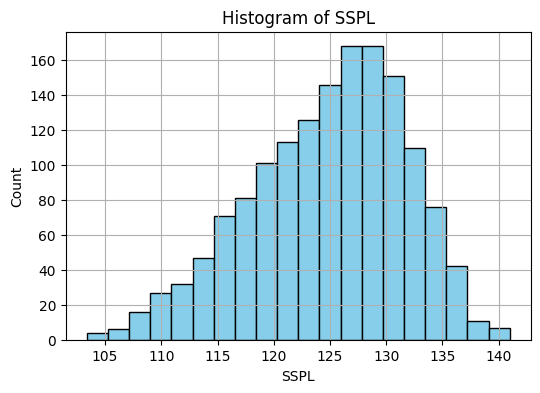

In [ ]:
# Histograms for each variable
for col in df.columns:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col], bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.grid(True)
    plt.show()

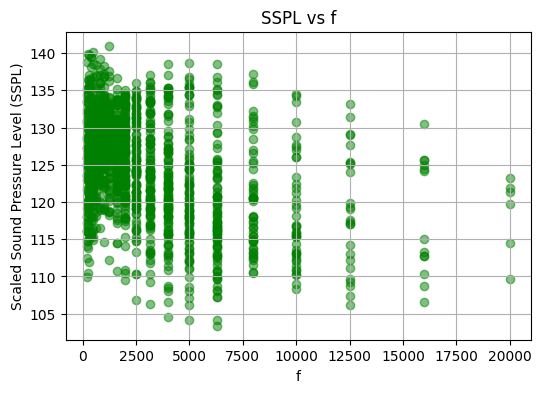

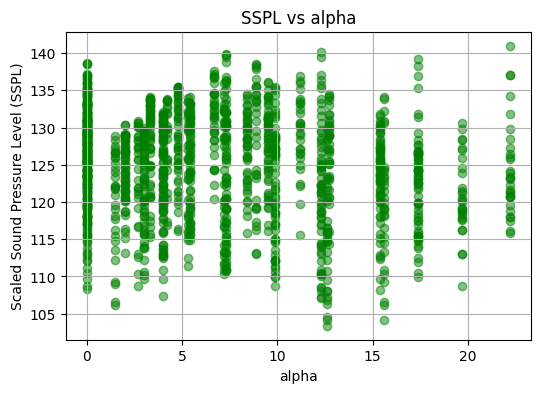

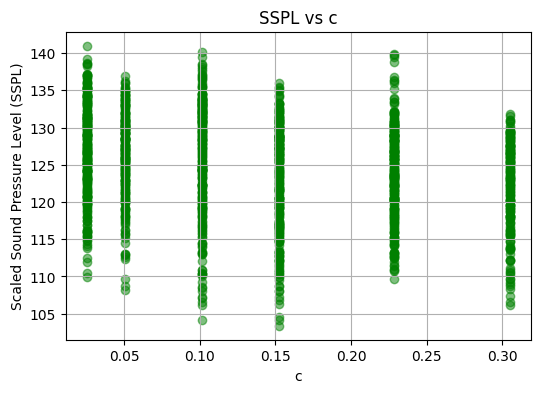

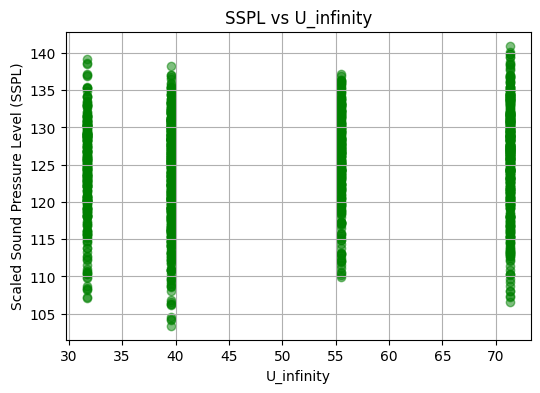

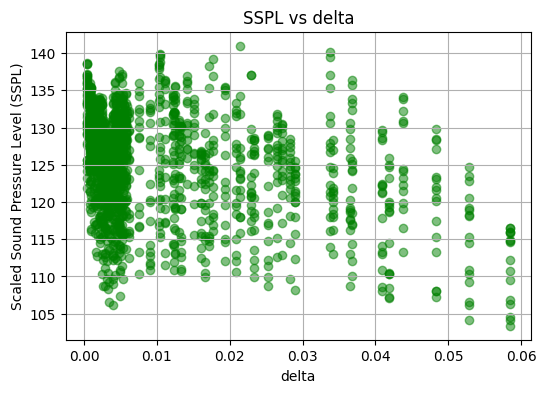

In [ ]:
input_cols = ['f', 'alpha', 'c', 'U_infinity', 'delta']
for col in input_cols:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[col], df['SSPL'], alpha=0.5, color='green')
    plt.title(f'SSPL vs {col}')
    plt.xlabel(col)
    plt.ylabel('Scaled Sound Pressure Level (SSPL)')
    plt.grid(True)
    plt.show()

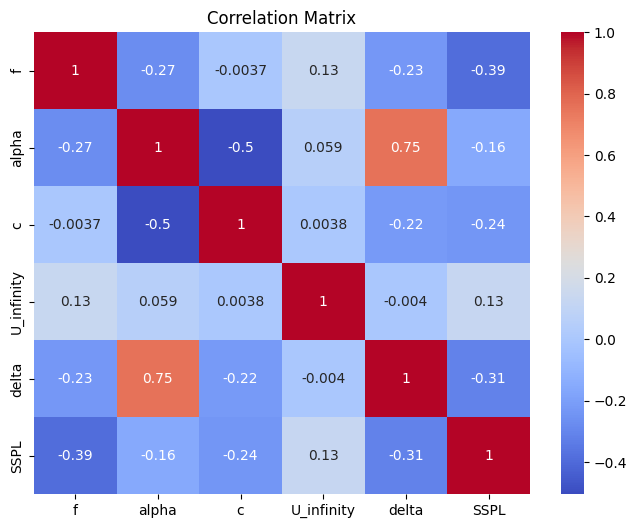

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


In [ ]:
# Descriptive statistics for each variable
print(df.describe().T)

# Skewness for each variable
print('Skewness:')
print(df.skew())

             count         mean          std         min         25%  \
f           1503.0  2886.380572  3152.573137  200.000000  800.000000   
alpha       1503.0     6.782302     5.918128    0.000000    2.000000   
c           1503.0     0.136548     0.093541    0.025400    0.050800   
U_infinity  1503.0    50.860745    15.572784   31.700000   39.600000   
delta       1503.0     0.011140     0.013150    0.000401    0.002535   
SSPL        1503.0   124.835943     6.898657  103.380000  120.191000   

                    50%          75%           max  
f           1600.000000  4000.000000  20000.000000  
alpha          5.400000     9.900000     22.200000  
c              0.101600     0.228600      0.304800  
U_infinity    39.600000    71.300000     71.300000  
delta          0.004957     0.015576      0.058411  
SSPL         125.721000   129.995500    140.987000  
Skewness:
f             2.137084
alpha         0.689164
c             0.457457
U_infinity    0.235852
delta         1.702165

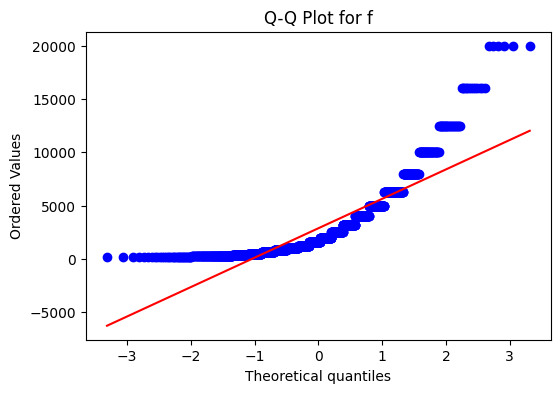

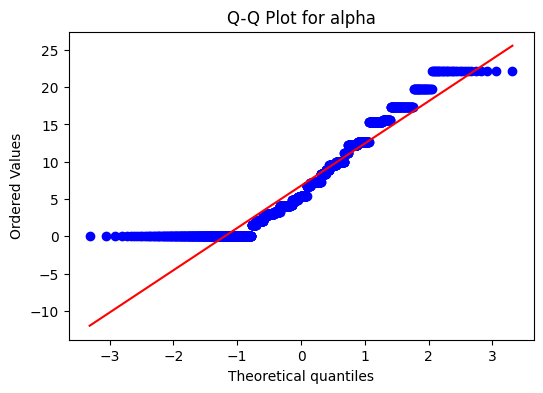

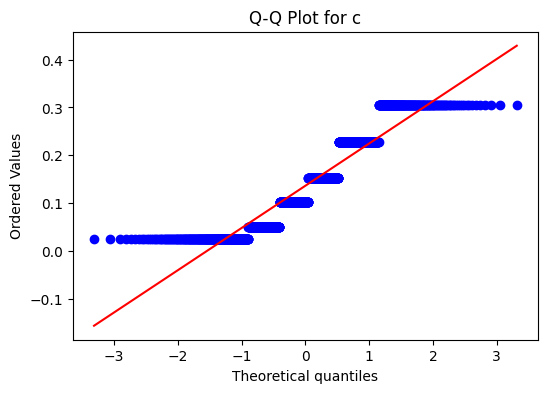

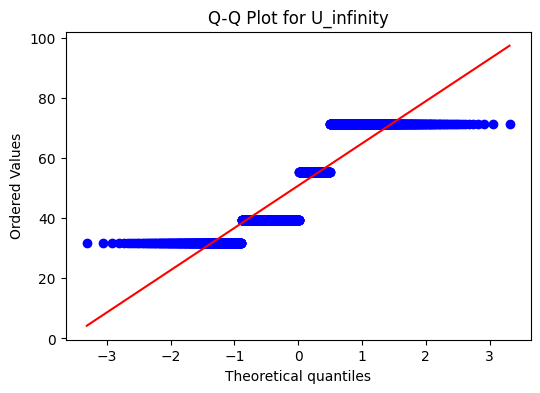

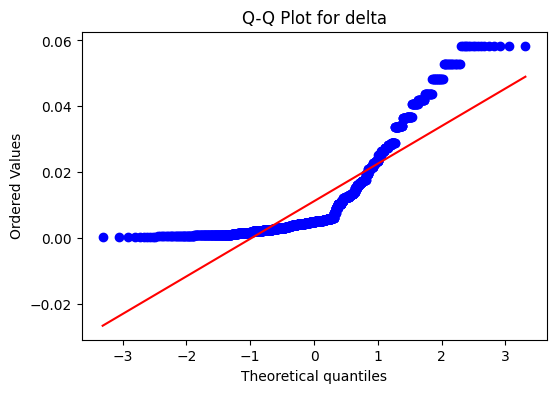

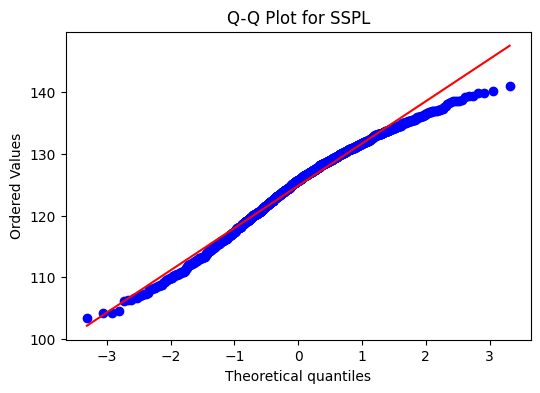

In [ ]:
import scipy.stats as stats
for col in df.columns:
    plt.figure(figsize=(6,4))
    stats.probplot(df[col], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot for {col}')
    plt.show()

In [ ]:
import numpy as np
import scipy.stats as stats
mean_sspl = np.mean(df['SSPL'])
std_sspl = np.std(df['SSPL'])
n = len(df['SSPL'])
ci = stats.norm.interval(0.95, loc=mean_sspl, scale=std_sspl/np.sqrt(n))
print(f"Mean SSPL: {mean_sspl:.2f}")
print(f"95% Confidence Interval: {ci}")

Mean SSPL: 124.84
95% Confidence Interval: (np.float64(124.48729363540272), np.float64(125.18459192680623))


In [ ]:
stat, pvalue = stats.ttest_1samp(df['SSPL'], 110)
print(f"T-test statistic: {stat:.2f}")
print(f"p-value: {pvalue:.4f}")
if mean_sspl < 110 and pvalue < 0.05:
    print('The mean SSPL is significantly less than 110.')
else:
    print('No significant evidence that mean SSPL is less than 110.')

T-test statistic: 83.37
p-value: 0.0000
No significant evidence that mean SSPL is less than 110.


In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop('SSPL', axis=1)
y = df['SSPL']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)
from sklearn.metrics import r2_score, mean_squared_error
print(f'R^2 score: {r2_score(y_test, y_pred):.2f}')
print(f'Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}')

R^2 score: 0.56
Root Mean Squared Error: 4.70


In [ ]:
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print(coefficients)

      Feature  Coefficient
0           f    -0.001272
1       alpha    -0.405660
2           c   -34.469438
3  U_infinity     0.098021
4       delta  -139.460274


In [ ]:
# Predict SSPL for your test data
predictions = model.predict(X_test)

# Find the test input set with the lowest predicted SSPL
quietest_idx = np.argmin(predictions)
quietest_input = X_test.iloc[quietest_idx]
quietest_predicted_sspl = predictions[quietest_idx]
print('Quietest input settings:')
print(quietest_input)
print(f'Predicted SSPL: {quietest_predicted_sspl:.2f}')

Quietest input settings:
f             20000.000000
alpha             4.800000
c                 0.025400
U_infinity       55.500000
delta             0.000873
Name: 1029, dtype: float64
Predicted SSPL: 109.59


In [ ]:
import pandas as pd

# Step 1: Specify number of input sets
num_sets = int(input('How many design input sets do you want to test? (Minimum: 2) '))

# Set up empty lists for each variable
frequency = []
angle_of_attack = []
chord_length = []
free_stream_velocity = []
suction_side_displacement_thickness = []

# Step 2: Prompt for each input set's values
for i in range(num_sets):
    print(f'---Input set {i+1}---')
    try:
        frequency.append(float(input('Frequency (f): ')))
        angle_of_attack.append(float(input('Angle of Attack (alpha): ')))
        chord_length.append(float(input('Chord Length (c): ')))
        free_stream_velocity.append(float(input('Free Stream Velocity (U_infinity): ')))
        suction_side_displacement_thickness.append(float(input('Suction Side Displacement Thickness (delta): ')))
    except ValueError:
        print("Invalid input. Please enter numeric values only.")
        # Optionally, you could break the loop or handle it differently
        break # Exit loop on invalid input for simplicity

# Step 3: Create DataFrame of input sets with correct column names
if len(frequency) == num_sets: # Only create DataFrame if all inputs were valid
    input_df = pd.DataFrame({
        'f': frequency,
        'alpha': angle_of_attack,
        'c': chord_length,
        'U_infinity': free_stream_velocity,
        'delta': suction_side_displacement_thickness
    })

    print('\nInput sets you provided:')
    display(input_df)
else:
    print("Input process interrupted due to invalid input.")

How many design input sets do you want to test? (Minimum: 2) 3
---Input set 1---
Frequency (f): 800
Angle of Attack (alpha): 0
Chord Length (c): 0.3048
Free Stream Velocity (U_infinity): 71.3
Suction Side Displacement Thickness (delta): 0.00266337
---Input set 2---
Frequency (f): 1000
Angle of Attack (alpha): 0
Chord Length (c): 0.3048
Free Stream Velocity (U_infinity): 71.3
Suction Side Displacement Thickness (delta): 0.00266337
---Input set 3---
Frequency (f): 1250
Angle of Attack (alpha): 0
Chord Length (c): 0.3048
Free Stream Velocity (U_infinity): 71.3
Suction Side Displacement Thickness (delta): 0.00266337

Input sets you provided:


,f,alpha,c,U_infinity,delta
0,800.0,0.0,0.3048,71.3,0.002663
1,1000.0,0.0,0.3048,71.3,0.002663
2,1250.0,0.0,0.3048,71.3,0.002663


In [ ]:
# Predict SSPL
predicted_sspl = model.predict(input_df)
input_df['Predicted_SSPL'] = predicted_sspl

# Display results
print('\nPredicted SSPL for each input set:')
print(input_df)

# Find the quietest design
quietest_index = input_df['Predicted_SSPL'].idxmin()
print(f'\nQuietest Design is Input Set {quietest_index + 1} with predicted SSPL of {input_df.loc[quietest_index, "Predicted_SSPL"]:.2f}')


Predicted SSPL for each input set:
        f  alpha       c  U_infinity     delta  Predicted_SSPL
0   800.0    0.0  0.3048        71.3  0.002663      127.625412
1  1000.0    0.0  0.3048        71.3  0.002663      127.371072
2  1250.0    0.0  0.3048        71.3  0.002663      127.053146

Quietest Design is Input Set 3 with predicted SSPL of 127.05
